# Data works

## Understand and clean up

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [9]:
d = pd.read_csv('books.csv')
d

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


In [10]:
d.columns

Index(['Name', 'Author', 'User Rating', 'Reviews', 'Price', 'Year', 'Genre'], dtype='str')

In [11]:
d.info()

<class 'pandas.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    str    
 1   Author       550 non-null    str    
 2   User Rating  550 non-null    float64
 3   Reviews      550 non-null    int64  
 4   Price        550 non-null    int64  
 5   Year         550 non-null    int64  
 6   Genre        550 non-null    str    
dtypes: float64(1), int64(3), str(3)
memory usage: 30.2 KB


In [12]:
d.isna().sum()

Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64

In [13]:
d.duplicated().sum()

np.int64(0)

### Drop duplicated names

In [14]:
d.duplicated('Name').sum() #199
d.drop_duplicates('Name', inplace=True)
d.duplicated('Name').sum() #0


np.int64(0)

In [15]:
d.to_csv('clean_books.csv', index=False)

### Data clean

## Visualise


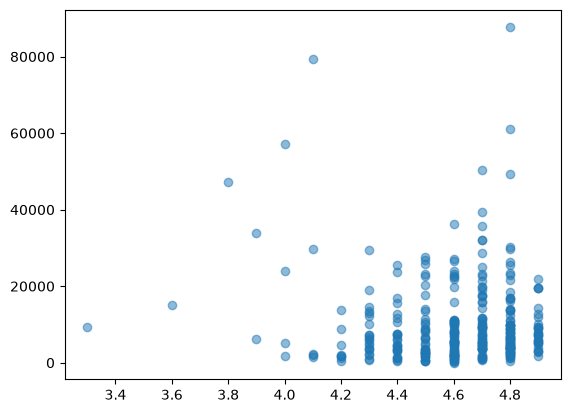

In [16]:
plt.scatter(d['User Rating'], d['Reviews'], alpha=0.5)
plt.show()

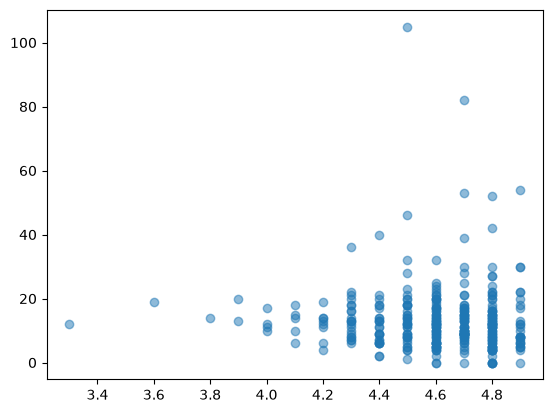

In [17]:

plt.scatter(d['User Rating'], d['Price'], alpha=0.5)
plt.show()
# No correlation between user rating and price


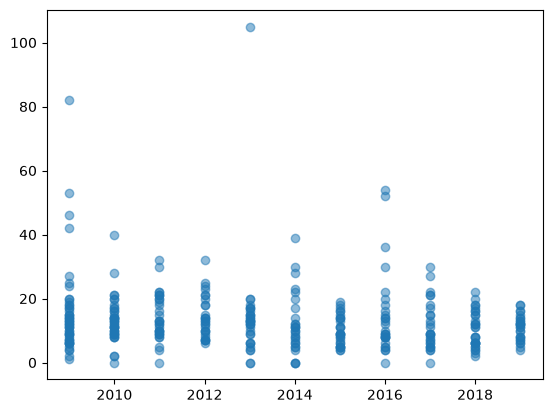

In [18]:
plt.scatter(d['Year'], d['Price'], alpha=0.5)
plt.show()
# consistent

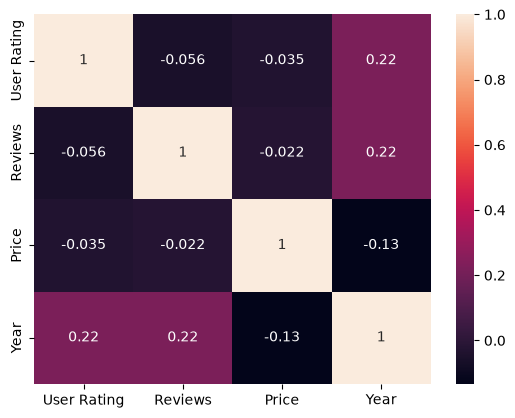

In [19]:
sns.heatmap(d.corr(numeric_only=True), annot=True)
plt.show()

### Encode non numerical types for heatmap

In [20]:
le = LabelEncoder()
d['Genre'] = le.fit_transform(d['Genre'])
d['Genre']

0      1
1      0
2      1
3      0
4      1
      ..
538    0
539    1
540    0
545    0
546    1
Name: Genre, Length: 351, dtype: int64

In [21]:
df = d.drop(['Name', 'Author'], axis=1)
df

,User Rating,Reviews,Price,Year,Genre
0,4.7,17350,8,2016,1
1,4.6,2052,22,2011,0
2,4.7,18979,15,2018,1
3,4.7,21424,6,2017,0
4,4.8,7665,12,2019,1
...,...,...,...,...,...
538,4.5,10760,15,2012,0
539,4.2,1302,11,2010,1
540,4.8,21625,9,2013,0
545,4.9,9413,8,2019,0


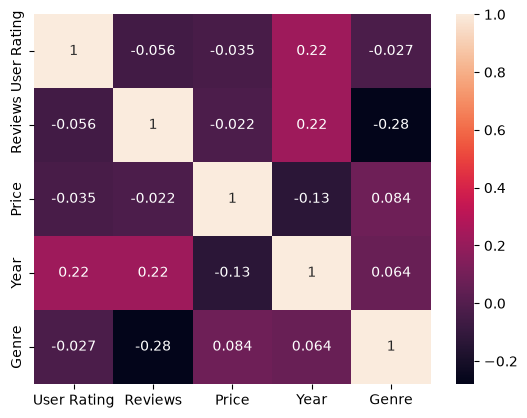

In [22]:
sns.heatmap(df.corr(), annot=True)
plt.show()